<a href="https://colab.research.google.com/github/MithravindaU/customer_sentimence_analysis_big_data/blob/main/Sentiment_Analysis_Using_PySpark_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
from google.colab import drive
import os

# Mount your Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
!pip install -q pyspark

In [74]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Sentiment140") \
    .master("local[*]") \
    .getOrCreate()

print("Spark Session Created Successfully!")

Spark Session Created Successfully!


In [80]:
csv_path = "/content/drive/MyDrive/bigdata/training.1600000.processed.noemoticon.csv"

In [76]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

schema = StructType([
    StructField("target", IntegerType(), True),
    StructField("id", StringType(), True),
    StructField("date", StringType(), True),
    StructField("query", StringType(), True),
    StructField("user", StringType(), True),
    StructField("text", StringType(), True)
])

In [81]:
df = spark.read.csv(
    csv_path,
    schema=schema,
    header=False
)

print("Rows:", df.count())
df.show(5)

Rows: 1600000
+------+----------+--------------------+--------+---------------+--------------------+
|target|        id|                date|   query|           user|                text|
+------+----------+--------------------+--------+---------------+--------------------+
|     0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|
|     0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|
|     0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|
|     0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|
|     0|1467811193|Mon Apr 06 22:19:...|NO_QUERY|         Karoli|@nationwideclass ...|
+------+----------+--------------------+--------+---------------+--------------------+
only showing top 5 rows


In [82]:
from pyspark.sql.functions import col, when

df = df.select("target", "text")

# Convert labels:
# 0 = Negative
# 4 = Positive -> 1

df = df.withColumn(
    "label",
    when(col("target") == 4, 1).otherwise(0)
).drop("target")

df.show(5)

+--------------------+-----+
|                text|label|
+--------------------+-----+
|@switchfoot http:...|    0|
|is upset that he ...|    0|
|@Kenichan I dived...|    0|
|my whole body fee...|    0|
|@nationwideclass ...|    0|
+--------------------+-----+
only showing top 5 rows


In [84]:
from pyspark.sql.functions import regexp_replace

df = df.withColumn(
    "clean_text",
    regexp_replace(
        col("text"),
        r"@[A-Za-z0-9_]+|https?://\S+|[^A-Za-z0-9\s]",
        ""
    )
)

df.select("label", "clean_text").show(5, truncate=False)

+-----+---------------------------------------------------------------------------------------------------------+
|label|clean_text                                                                                               |
+-----+---------------------------------------------------------------------------------------------------------+
|0    |   Awww thats a bummer  You shoulda got David Carr of Third Day to do it D                               |
|0    |is upset that he cant update his Facebook by texting it and might cry as a result  School today also Blah|
|0    | I dived many times for the ball Managed to save 50  The rest go out of bounds                           |
|0    |my whole body feels itchy and like its on fire                                                           |
|0    | no its not behaving at all im mad why am i here because I cant see you all over there                   |
+-----+---------------------------------------------------------------------------------

In [85]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline

tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words"
)

hashingTF = HashingTF(
    inputCol="filtered_words",
    outputCol="rawFeatures",
    numFeatures=10000
)

idf = IDF(
    inputCol="rawFeatures",
    outputCol="features"
)

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    idf
])

pipeline_model = pipeline.fit(df)

dataset = pipeline_model.transform(df)

dataset.select("features", "label").show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|(10000,[1528,2306...|    0|
|(10000,[399,1939,...|    0|
|(10000,[1708,2708...|    0|
|(10000,[627,841,1...|    0|
|(10000,[1616,2007...|    0|
+--------------------+-----+
only showing top 5 rows


In [ ]:
train_data,test_data = dataset.randomSplit(
    [0.8,0.2],
    seed=42
)

In [ ]:
import time

start = time.time()
end = time.time()

print("Training Time:",end-start,"seconds")

Training Time: 8.416175842285156e-05 seconds


In [ ]:
from pyspark.ml.classification import RandomForestClassifier

train_data, test_data = dataset.randomSplit([0.8, 0.2], seed=42)

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20,
    maxDepth=8
)

print("Training model...")
rf_model = rf.fit(train_data)

print("Training Complete!")

Training model...
Training Complete!


In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

predictions = rf_model.transform(test_data)

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 66.52%


In [ ]:
sample = spark.createDataFrame([
    ("I absolutely love this movie!",),
    ("This product is terrible.",)
], ["clean_text"])

sample_data = pipeline_model.transform(sample)
pred = rf_model.transform(sample_data)

pred.select("clean_text", "prediction").show(truncate=False)

+-----------------------------+----------+
|clean_text                   |prediction|
+-----------------------------+----------+
|I absolutely love this movie!|1.0       |
|This product is terrible.    |1.0       |
+-----------------------------+----------+



In [87]:
rf_model.write().overwrite().save("/content/drive/MyDrive/Sentiment_RF_Model")

In [88]:
sample = spark.createDataFrame([
    ("I absolutely love this movie!",),
    ("This product is terrible.",)
], ["clean_text"])

sample_data = pipeline_model.transform(sample)
pred = rf_model.transform(sample_data)

pred.select("clean_text", "prediction").show(truncate=False)

+-----------------------------+----------+
|clean_text                   |prediction|
+-----------------------------+----------+
|I absolutely love this movie!|1.0       |
|This product is terrible.    |1.0       |
+-----------------------------+----------+



In [ ]:
from pyspark.sql.functions import count

class_distribution = df.groupBy("label").count()

class_distribution.show()

import matplotlib.pyplot as plt

labels = []
counts = []

for row in class_distribution.collect():
    labels.append("Positive" if row["label"] == 1 else "Negative")
    counts.append(row["count"])

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Tweet Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

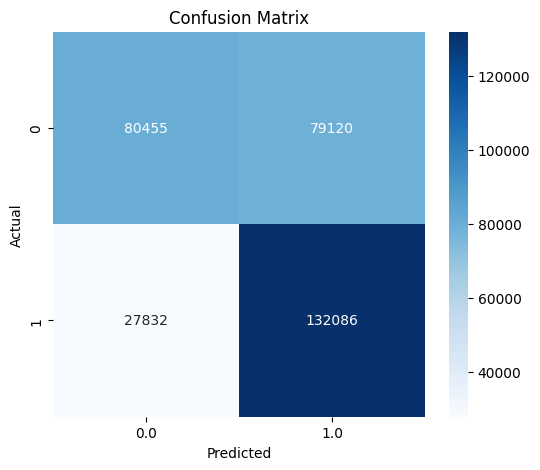

In [90]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cm_df = cm.toPandas()

pivot = cm_df.pivot(
    index="label",
    columns="prediction",
    values="count"
).fillna(0)

plt.figure(figsize=(6,5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [91]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = ["accuracy","weightedPrecision","weightedRecall","f1"]

for metric in metrics:

    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(predictions)

    print(f"{metric}: {score:.4f}")

accuracy: 0.6652
weightedPrecision: 0.6841
weightedRecall: 0.6652
f1: 0.6563


In [92]:
from pyspark.sql import Row

sample = spark.createDataFrame([
    Row(clean_text="I absolutely love this phone"),
    Row(clean_text="This movie is the worst ever"),
    Row(clean_text="The food was amazing"),
    Row(clean_text="I hate this product")
])

sample = pipeline_model.transform(sample)

result = rf_model.transform(sample)

result.select(
    "clean_text",
    "prediction"
).show(truncate=False)

+----------------------------+----------+
|clean_text                  |prediction|
+----------------------------+----------+
|I absolutely love this phone|1.0       |
|This movie is the worst ever|1.0       |
|The food was amazing        |1.0       |
|I hate this product         |0.0       |
+----------------------------+----------+



In [93]:
rf_model.write().overwrite().save(
"/content/drive/MyDrive/Sentiment_RF_Model"
)

In [94]:
predictions.select(
    "label",
    "prediction"
).write.mode("overwrite").csv(
"/content/drive/MyDrive/Predictions"
)

In [95]:
df.select(
    "text",
    "clean_text"
).show(10,truncate=False)

+-------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+
|text                                                                                                               |clean_text                                                                                               |
+-------------------------------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------------+
|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D|   Awww thats a bummer  You shoulda got David Carr of Third Day to do it D                               |
|is upset that he can't update his Facebook by texting it... and might cry as a result  School today als

In [96]:
print(rf_model.featureImportances)

(10000,[8,15,23,44,71,78,88,90,150,157,198,206,208,226,231,269,275,281,316,349,354,387,402,415,418,419,429,433,439,468,469,473,493,495,506,516,527,533,538,557,560,574,576,585,613,619,668,672,673,701,710,741,750,757,798,841,857,870,903,922,923,926,961,993,999,1017,1020,1023,1064,1071,1072,1073,1088,1092,1097,1149,1158,1175,1180,1194,1195,1198,1233,1311,1329,1340,1348,1383,1384,1390,1408,1433,1506,1508,1517,1548,1565,1574,1578,1583,1586,1590,1597,1600,1611,1623,1626,1634,1662,1681,1687,1703,1708,1711,1738,1767,1778,1790,1803,1805,1808,1817,1821,1847,1850,1870,1886,1903,1925,1929,1955,1959,1972,2001,2007,2069,2070,2072,2109,2158,2180,2199,2207,2240,2265,2275,2280,2286,2297,2309,2310,2318,2323,2335,2346,2355,2358,2366,2403,2407,2408,2409,2415,2422,2425,2427,2433,2481,2486,2492,2500,2505,2534,2537,2543,2588,2589,2610,2630,2657,2665,2687,2688,2696,2700,2707,2716,2726,2752,2790,2801,2804,2832,2838,2842,2867,2871,2912,2933,2944,2980,2987,3048,3068,3080,3098,3115,3120,3131,3136,3139,3144,3160,3

In [98]:
# Install ipywidgets if needed
!pip install -q ipywidgets

import ipywidgets as widgets
from IPython.display import display, Markdown
from pyspark.sql import Row

# Create widgets
review_box = widgets.Textarea(
    value='',
    placeholder='Type your review here...',
    description='Review:',
    layout=widgets.Layout(width='100%', height='120px')
)

predict_button = widgets.Button(
    description='Predict Sentiment',
    button_style='success',
    icon='check'
)

output = widgets.Output()

# Prediction function
def predict_sentiment(button):

    with output:
        output.clear_output()

        review = review_box.value.strip()

        if review == "":
            display(Markdown("### ⚠ Please enter a review."))
            return

        # Create Spark DataFrame
        sample = spark.createDataFrame(
            [Row(clean_text=review)]
        )

        # Apply preprocessing pipeline
        sample = pipeline_model.transform(sample)

        # Predict
        prediction = rf_model.transform(sample).collect()[0]

        sentiment = int(prediction["prediction"])

        if sentiment == 1:
            display(Markdown(
                f"""
## 😊 Positive Review

**Review**

> {review}

**Prediction**

The model predicts this review is **POSITIVE**.
"""
            ))
        else:
            display(Markdown(
                f"""
## 😞 Negative Review

**Review**

> {review}

**Prediction**

The model predicts this review is **NEGATIVE**.
"""
            ))

predict_button.on_click(predict_sentiment)

display(Markdown("# 🎯 Live Sentiment Analyzer"))
display(review_box)
display(predict_button)
display(output)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 61.7 MB/s eta 0:00:00


# 🎯 Live Sentiment Analyzer

Textarea(value='', description='Review:', layout=Layout(height='120px', width='100%'), placeholder='Type your …

Button(button_style='success', description='Predict Sentiment', icon='check', style=ButtonStyle())

Output()